<a href="https://colab.research.google.com/github/paramita-pp/time-series-analysis/blob/main/Holt_Winters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Time Series Analysis/Exponential Smoothing and Holt Winters

/content/drive/MyDrive/Time Series Analysis/Exponential Smoothing and Holt Winters


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [4]:
# Set the index when we import the data
df = pd.read_csv('weekly_customer_complaints.csv', index_col = 'week', parse_dates= True)
df.head()

,complaints,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [5]:
# change the name of time series variable to y
df = df.rename(columns = {'complaints': 'y'})
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,"1,750",37.26%,1,0,0
2018-01-08,"1,701",35.38%,0,0,0
2018-01-15,"1,711",36.22%,1,0,0
2018-01-22,"1,443",38.33%,1,0,0
2018-01-29,"1,397",36.34%,0,0,0


In [6]:
# Preview df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 261 entries, 2018-01-01 to 2022-12-26
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   y                        261 non-null    object
 1   discount_rate            261 non-null    object
 2   small_commercial_event   261 non-null    int64 
 3   medium_commercial_event  261 non-null    int64 
 4   big_commercial_event     261 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 12.2+ KB


In [7]:
# Remove the comma from df.y and transform to integer
df['y'] = df['y'].str.replace(',', '').astype(int)
df.head()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2018-01-01,1750,37.26%,1,0,0
2018-01-08,1701,35.38%,0,0,0
2018-01-15,1711,36.22%,1,0,0
2018-01-22,1443,38.33%,1,0,0
2018-01-29,1397,36.34%,0,0,0


# Data Visualization

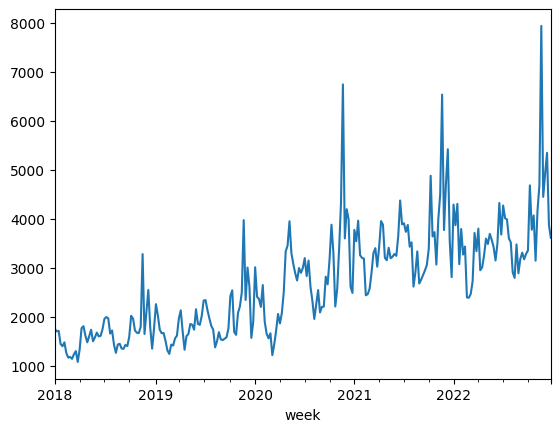

In [8]:
# Time series plot
df['y'].plot()
plt.show()

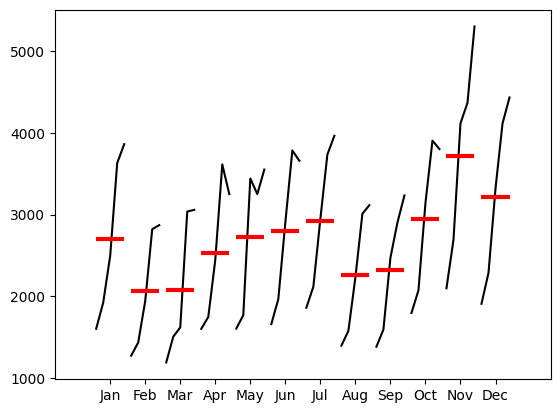

In [9]:
# Plot the month_plot
month_plot(df['y'].resample('ME').mean())
plt.show()

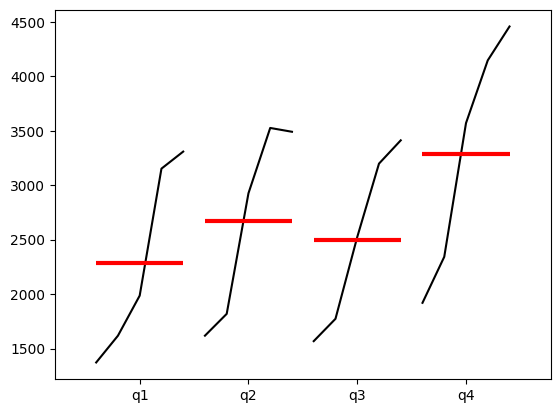

In [10]:
# Plot the quarter_plot
quarter_plot(df['y'].resample('QE').mean())
plt.show()

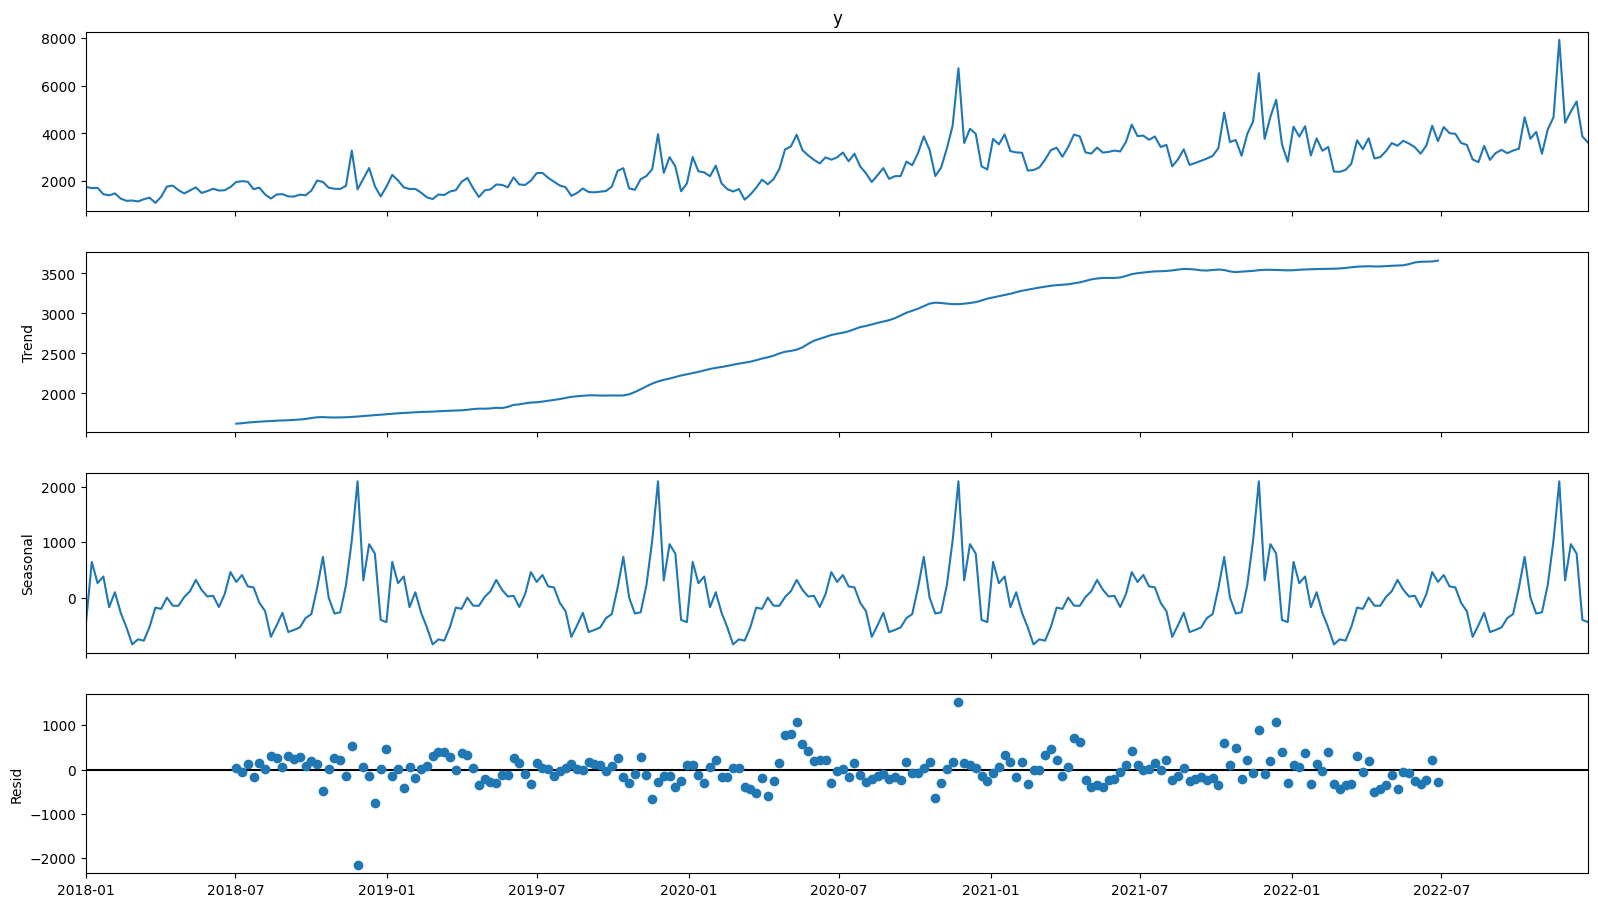

In [11]:
# Seasonal decomposition for df[]
decomposition = seasonal_decompose(df['y'],
                                   model = 'additive',
                                   period = 52)

# Get the figure from the plot method of decomposition
fig = decomposition.plot()
fig.set_size_inches(18, 10)
plt.show()

# (Partial) Auto Correlation

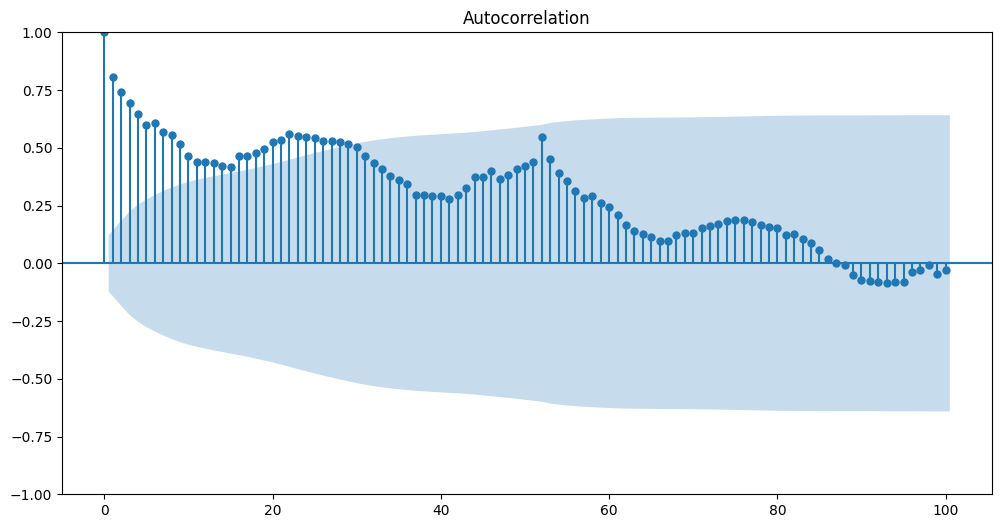

In [12]:
# Plot the ACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(df['y'], lags = 100, ax = ax)
plt.show()

ACF Interpretation:
- Spike at week 52

PACF
- Week 2, 6, 16, 52 -> Need seasonality -> Holt-winter

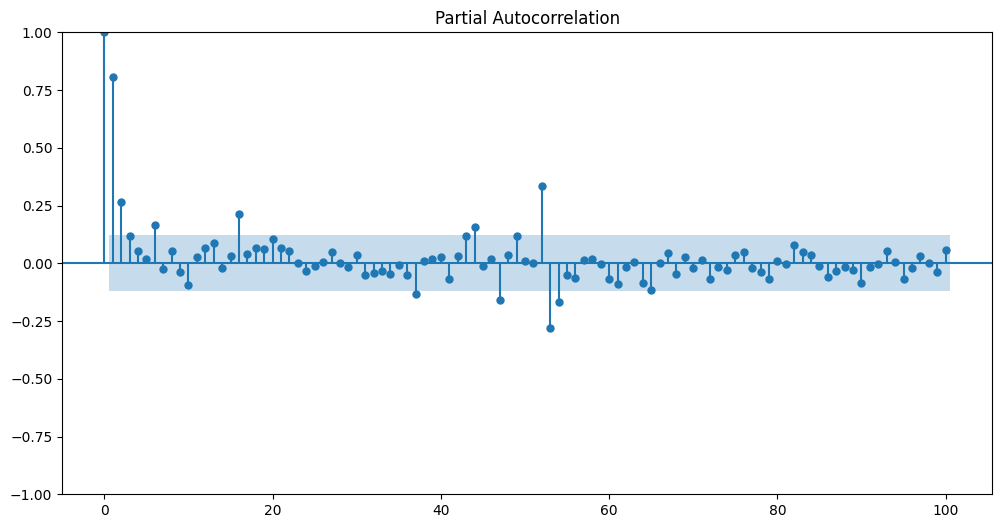

In [13]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(df['y'], lags = 100, ax = ax)
plt.show()

# Time Series Frequency

In [14]:
# Print the frequency of the time series
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq=None)

In [15]:
df.index.freq = 'W-Mon'
df.index

DatetimeIndex(['2018-01-01', '2018-01-08', '2018-01-15', '2018-01-22',
               '2018-01-29', '2018-02-05', '2018-02-12', '2018-02-19',
               '2018-02-26', '2018-03-05',
               ...
               '2022-10-24', '2022-10-31', '2022-11-07', '2022-11-14',
               '2022-11-21', '2022-11-28', '2022-12-05', '2022-12-12',
               '2022-12-19', '2022-12-26'],
              dtype='datetime64[ns]', name='week', length=261, freq='W-MON')

# Training and Test

## Goal: Predict the next 13 weeks

In [16]:
# Split the data into training and test
periods = 13
train = df[:-periods].y
test = df[-periods:].y

In [17]:
train.tail()

,y
week,
2022-08-29,2885
2022-09-05,3177
2022-09-12,3306
2022-09-19,3170
2022-09-26,3279


In [18]:
# Other way to split data
train, test = df.iloc[:-periods, 0], df.iloc[-periods:, 0]

# Simple Exponential Smoothing
First value will use as level

In [19]:
# Apply SES to the train data
ses_model = SimpleExpSmoothing(train).fit()
print(ses_model.summary())

                       SimpleExpSmoothing Model Results                       
Dep. Variable:                      y   No. Observations:                  248
Model:             SimpleExpSmoothing   SSE                       74355478.081
Optimized:                       True   AIC                           3131.513
Trend:                           None   BIC                           3138.540
Seasonal:                        None   AICC                          3131.678
Seasonal Periods:                None   Date:                 Sat, 17 Jan 2026
Box-Cox:                        False   Time:                         02:47:10
Box-Cox Coeff.:                  None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5097819                alpha                 True
initial_level              1750.0000                

In [20]:
# Predictions
ses_pred = ses_model.forecast(periods)
ses_pred

,0
2022-10-03,3236.663473
2022-10-10,3236.663473
2022-10-17,3236.663473
2022-10-24,3236.663473
2022-10-31,3236.663473
2022-11-07,3236.663473
2022-11-14,3236.663473
2022-11-21,3236.663473
2022-11-28,3236.663473
2022-12-05,3236.663473


In [21]:
# Compute with the initial level
train.iloc[-1] * 0.51 + 1750

np.float64(3422.29)

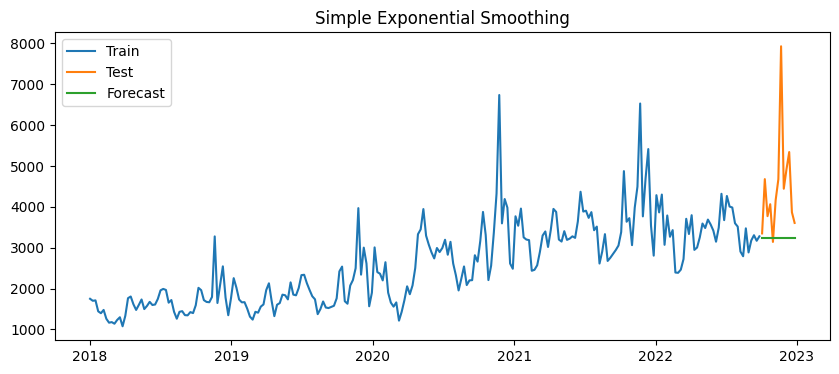

In [22]:
# Set the size of the plot of 10 by 4
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train, label = "Train")
plt.plot(test, label = "Test")
plt.plot(ses_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Simple Exponential Smoothing")
plt.legend()
plt.show()

# Double Exponential Smoothing

In [23]:
# Build the model
model_double = ExponentialSmoothing(endog = train,
                                        trend = 'add',
                                        seasonal = None).fit()
print(model_double.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  248
Model:             ExponentialSmoothing   SSE                       74343958.374
Optimized:                         True   AIC                           3135.474
Trend:                         Additive   BIC                           3149.528
Seasonal:                          None   AICC                          3135.823
Seasonal Periods:                  None   Date:                 Sat, 17 Jan 2026
Box-Cox:                          False   Time:                         02:47:13
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.5093872                alpha                 True
smoothing_trend             0.0000

In [24]:
# Predict with the Double ES model
double_pred = model_double.forecast(periods)
double_pred

,0
2022-10-03,3248.184263
2022-10-10,3254.072668
2022-10-17,3259.961074
2022-10-24,3265.849480
2022-10-31,3271.737885
2022-11-07,3277.626291
2022-11-14,3283.514697
2022-11-21,3289.403102
2022-11-28,3295.291508
2022-12-05,3301.179913


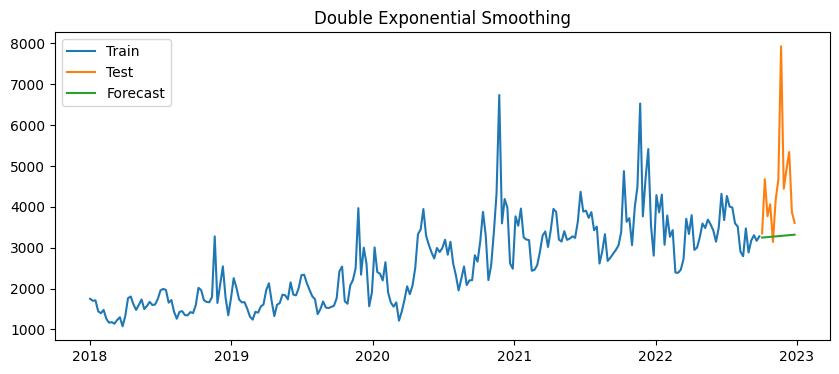

In [25]:
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train, label = "Train")
plt.plot(test, label = "Test")
plt.plot(double_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Double Exponential Smoothing")
plt.legend()
plt.show()

# Holt-Winter (Triple Exponential Smoothing)

Holt-Winters is highly effective in forecasting with recurring patterns.
- alpha: control level
- beta: control trend
- gemma: control seasonality

This method is good for handling intricate patterns in time-series.

In [26]:
# Build the Holt-Winters model
model_holt = ExponentialSmoothing(endog = train,
                                        trend = 'mul',
                                        seasonal = 'mul',
                                        seasonal_periods = 52).fit()
print(model_holt.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                        y   No. Observations:                  248
Model:             ExponentialSmoothing   SSE                       21601472.986
Optimized:                         True   AIC                           2932.961
Trend:                   Multiplicative   BIC                           3129.713
Seasonal:                Multiplicative   AICC                          2969.173
Seasonal Periods:                    52   Date:                 Sat, 17 Jan 2026
Box-Cox:                          False   Time:                         02:47:17
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.2517327                alpha                 True
smoothing_trend          

In [27]:
# Predict with the Holt-Winters model
holt_pred = model_holt.forecast(periods)
holt_pred

,0
2022-10-03,4056.273947
2022-10-10,5067.514342
2022-10-17,3957.752185
2022-10-24,3558.629819
2022-10-31,3468.242492
2022-11-07,4300.143141
2022-11-14,5404.309802
2022-11-21,7319.519337
2022-11-28,4409.655503
2022-12-05,5382.927578


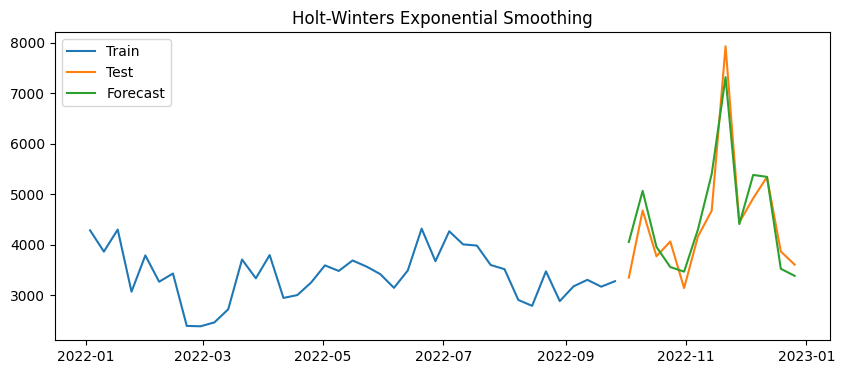

In [28]:
plt.figure(figsize = (10, 4))

# Plot the train, test and forecast data
plt.plot(train.loc['2022'], label = "Train")
plt.plot(test, label = "Test")
plt.plot(holt_pred, label = "Forecast")

# Add a title and legend to the plot
plt.title("Holt-Winters Exponential Smoothing")
plt.legend()
plt.show()

In [29]:
# Calculate and print the RMSE, MAE, and MAPE
rmse = root_mean_squared_error(test, holt_pred)
mae = mean_absolute_error(test, holt_pred)
mape = mean_absolute_percentage_error(test, holt_pred)

print(f"RMSE: {rmse:.0f}")
print(f"MAE: {mae:.0f}")
print(f"MAPE: {mape * 100:.1f} %")

RMSE: 425
MAE: 358
MAPE: 8.4 %


RMSE: 425
MAE: 364
MAPE: 8.4 %

In [30]:
# Function the assesses the model and visualzies the train, test, and forecast
def model_assessment(train, test, predictions, chart_title = None):
    # Set the size of the plot of 10 by 4
    plt.figure(figsize = (10, 4))

    # Plot the train, test and forecast data
    plt.plot(train, label = "Train")
    plt.plot(test, label = "Test")
    plt.plot(predictions, label = "Forecast")

    # Add a title and legend to the plot
    if chart_title:
        plt.title(chart_title)
    plt.legend()
    plt.show()

    # Calculate and print RMSE, MAE, and MAPE
    print(f"RMSE: {rmse:.0f}")
    print(f"MAE: {mae:.0f}")
    print(f"MAPE: {mape * 100:.1f} %")

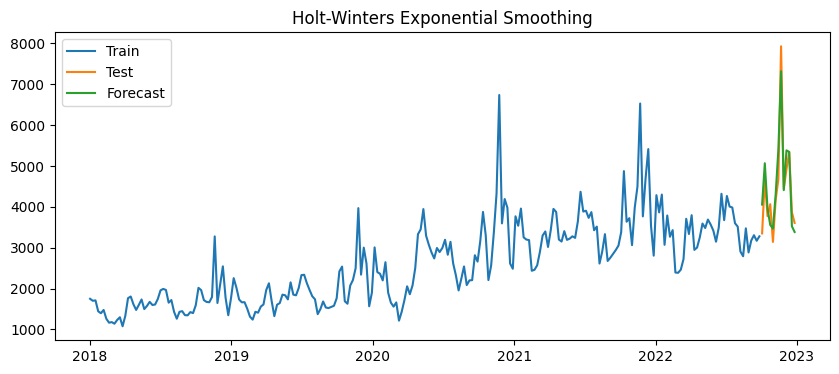

RMSE: 425
MAE: 358
MAPE: 8.4 %


In [31]:
# Apply the function
model_assessment(train, test, holt_pred, "Holt-Winters Exponential Smoothing")


# Predict the future

In [32]:
df.tail()

,y,discount_rate,small_commercial_event,medium_commercial_event,big_commercial_event
week,,,,,
2022-11-28,4444,29.89%,0,1,0
2022-12-05,4920,28.48%,1,0,0
2022-12-12,5342,28.89%,0,0,0
2022-12-19,3868,33.26%,0,0,0
2022-12-26,3607,37.35%,0,1,0


In [33]:
# Build a Holt Winters model with the complete data
model_holt_complete = ExponentialSmoothing(
    endog = df.y,
    trend = 'add',
    seasonal = 'mul',
    seasonal_periods = 52
).fit()

In [34]:
# Predict with the model
forecast = model_holt_complete.forecast(13)
forecast

,0
2023-01-02,4965.837323
2023-01-09,4478.091513
2023-01-16,4699.515551
2023-01-23,3814.120124
2023-01-30,4242.022859
2023-02-06,3726.289686
2023-02-13,3385.531813
2023-02-20,2879.458647
2023-02-27,2978.582150
2023-03-06,3044.198652


In [35]:
def plot_forecast(y, forecast, chart_title = None):

    # Plot the training data and forecast
    plt.figure(figsize = (10, 4))

    # Plot the train, test, and forecast
    plt.plot(y, label = "Train")
    plt.plot(forecast, label = "Forecast")

    # Add a title and legend to the plot
    plt.title(chart_title)
    plt.legend()
    plt.show()



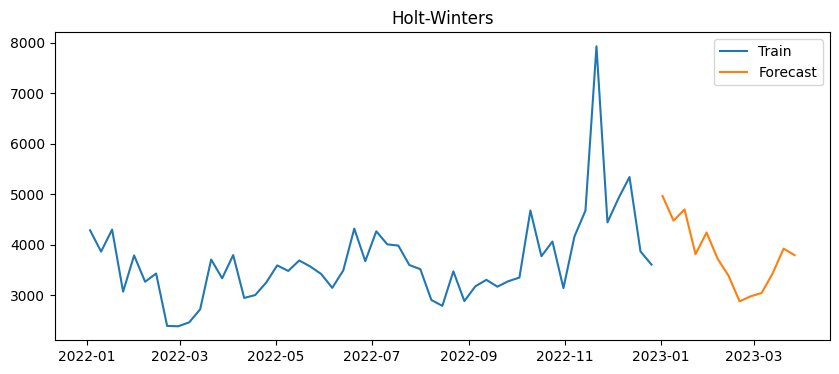

In [36]:
# Apply the function
plot_forecast(df['y'].loc['2022'], forecast, 'Holt-Winters')

# Daily Data

In [37]:
# LOading the Bitcoin price data
df_daily = pd.read_csv('bitcoin_price.csv', index_col= 'Date', parse_dates = True)['Adj Close'].rename('y')
df_daily.head()

,y
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014


In [38]:
# Setting the index frequency to daily
df_daily = df_daily.asfreq('D')
df_daily.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30'],
              dtype='datetime64[ns]', name='Date', length=3392, freq='D')

# Model Assessment

In [39]:
# Set the test data to 30 days
periods = 30
train, test = df_daily.iloc[:-periods], df_daily.iloc[-periods:]

In [ ]:
train

,y
Date,
2014-09-17,457.334015
2014-09-18,424.440002
2014-09-19,394.795990
2014-09-20,408.903992
2014-09-21,398.821014
...,...
2023-11-26,37479.121094
2023-11-27,37254.167969
2023-11-28,37831.085938


In [ ]:
test

,y
Date,
2023-12-01,38688.750000
2023-12-02,39476.332031
2023-12-03,39978.390625
2023-12-04,41980.097656
2023-12-05,44080.648438
2023-12-06,43746.445312
2023-12-07,43292.664062
2023-12-08,44166.601562
2023-12-09,43725.984375


In [42]:
# Build a holt-winters model
model_daily = ExponentialSmoothing(
    endog = train,
    trend = 'mul',
    seasonal = 'mul',
    seasonal_periods = 365
).fit()

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


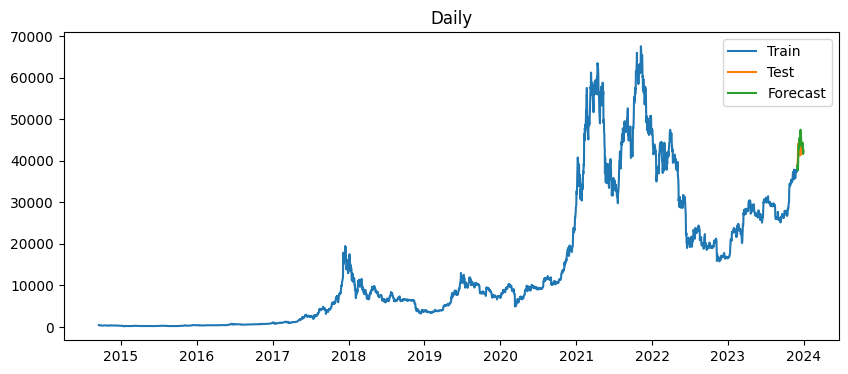

RMSE: 425
MAE: 358
MAPE: 8.4 %


In [43]:
# Predict with the Holt Winters
daily_pred = model_daily.forecast(periods)

# Assess the model
model_assessment(train, test, daily_pred, 'Daily')